In [1]:
import numpy as np 
import pandas as pd 
import math
import random
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn import metrics
from sklearn import svm
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.dummy import DummyClassifier
from imblearn.metrics import geometric_mean_score

In [2]:
data=pd.read_csv("balance-scale.csv")

In [3]:
import sklearn
sklearn.__version__

'1.0.2'

In [4]:
data.columns=["id","Class","Oxin","Onine","Hormone","Tsh"]

In [5]:
data.set_index("id", inplace=True)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 624 entries, 2 to 625
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Class    624 non-null    object
 1   Oxin     624 non-null    int64 
 2   Onine    624 non-null    int64 
 3   Hormone  624 non-null    int64 
 4   Tsh      624 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 29.2+ KB


In [7]:
data

,Class,Oxin,Onine,Hormone,Tsh
id,,,,,
2,R,1,1,1,2
3,R,1,1,1,3
4,R,1,1,1,4
5,R,1,1,1,5
6,R,1,1,2,1
...,...,...,...,...,...
621,L,5,5,5,1
622,L,5,5,5,2
623,L,5,5,5,3


In [8]:
data.Class = pd.factorize(data.Class)[0] + 1

In [9]:
gb=data.groupby("Class")

In [10]:
for Class, Class_df in gb:
    print(Class)
    print(Class_df)

1
     Class  Oxin  Onine  Hormone  Tsh
id                                   
2        1     1      1        1    2
3        1     1      1        1    3
4        1     1      1        1    4
5        1     1      1        1    5
6        1     1      1        2    1
..     ...   ...    ...      ...  ...
569      1     5      3        4    4
570      1     5      3        4    5
574      1     5      3        5    4
575      1     5      3        5    5
600      1     5      4        5    5

[288 rows x 5 columns]
2
     Class  Oxin  Onine  Hormone  Tsh
id                                   
26       2     1      2        1    1
51       2     1      3        1    1
52       2     1      3        1    2
56       2     1      3        2    1
76       2     1      4        1    1
..     ...   ...    ...      ...  ...
620      2     5      5        4    5
621      2     5      5        5    1
622      2     5      5        5    2
623      2     5      5        5    3
624      2     5      

In [11]:
gb.get_group(1)

,Class,Oxin,Onine,Hormone,Tsh
id,,,,,
2,1,1,1,1,2
3,1,1,1,1,3
4,1,1,1,1,4
5,1,1,1,1,5
6,1,1,1,2,1
...,...,...,...,...,...
569,1,5,3,4,4
570,1,5,3,4,5
574,1,5,3,5,4


In [12]:
class_samples=gb.get_group(1).sample(n=15)
#    print(class_samples)

In [13]:
print(type(class_samples))

<class 'pandas.core.frame.DataFrame'>


In [14]:
mean_sum=class_samples["Oxin"].mean() + class_samples["Onine"].mean() + class_samples["Hormone"].mean() + class_samples["Tsh"].mean()

In [15]:
column_length=len(data.columns) -1

In [16]:
similar_val_1=mean_sum/column_length
print(similar_val_1)

3.166666666666667


In [17]:
class_2_samples=gb.get_group(2).sample(n=15)
#    print(class_2_samples)

In [18]:
mean_sum_2=class_2_samples["Oxin"].mean() + class_2_samples["Onine"].mean() + class_2_samples["Hormone"].mean() + class_2_samples["Tsh"].mean()

In [19]:
similar_val_2=mean_sum_2/column_length
print(similar_val_2)

2.933333333333333


In [20]:
class_3_samples=gb.get_group(3).sample(n=15)
#    print(class_3_samples)

In [21]:
mean_sum_3=class_3_samples["Oxin"].mean() + class_3_samples["Onine"].mean() + class_3_samples["Hormone"].mean() + class_3_samples["Tsh"].mean()

In [22]:
similar_val_3=mean_sum_3/column_length
print(similar_val_3)

3.0


In [23]:
sim_23=abs(similar_val_3 - similar_val_2)
sim_23=sim_23/10
sim_23=1 - sim_23

sim_12=abs(similar_val_1 - similar_val_2)
sim_12=sim_12/10
sim_12=1 - sim_12

sim_13=abs(similar_val_3 - similar_val_1)
sim_13=sim_13/10
sim_13=1 - sim_13

print("Similarity between 2 and 3: ", sim_23)
print("Similarity between 2 and 1: ", sim_12)
print("Similarity between 1 and 3: ", sim_13)

Similarity between 2 and 3:  0.9933333333333333
Similarity between 2 and 1:  0.9766666666666666
Similarity between 1 and 3:  0.9833333333333333


In [178]:
gb.size()

Class
1    288
2    288
3     48
dtype: int64

In [25]:
m=math.ceil((288+48)/2)

In [26]:
print(m)

168


In [27]:
len(gb)

3

In [28]:
neigh = KNeighborsClassifier(n_neighbors=6)

In [29]:
#neigh.fit(X_train, Y_train)
neigh.fit(data, data.Class)

KNeighborsClassifier(n_neighbors=6)

In [30]:
result=neigh.kneighbors(data, return_distance=True)

In [31]:
print(type(result))

<class 'tuple'>


In [32]:
print(result)

(array([[0.        , 1.        , 1.        , 1.41421356, 1.41421356,
        1.41421356],
       [0.        , 1.        , 1.        , 1.        , 1.        ,
        1.        ],
       [0.        , 1.        , 1.        , 1.        , 1.        ,
        1.        ],
       ...,
       [0.        , 1.        , 1.        , 1.        , 1.        ,
        1.        ],
       [0.        , 1.        , 1.        , 1.41421356, 1.41421356,
        1.41421356],
       [0.        , 1.41421356, 1.41421356, 1.41421356, 1.41421356,
        1.41421356]]), array([[  0,   1,   5,  30, 130,   4],
       [  1,   2, 126,   0,   6,  26],
       [  2,   1, 127,   3,  27,   7],
       ...,
       [621, 622, 596, 620, 496, 616],
       [622, 617, 621, 596, 497, 616],
       [623, 493, 597, 622, 497, 618]], dtype=int64))


In [33]:
arr1=result[0]

In [34]:
print(type(arr1))

<class 'numpy.ndarray'>


In [35]:
print(arr1.ndim)

2


In [36]:
arr2=result[1]

In [37]:
print(type(arr2))

<class 'numpy.ndarray'>


In [38]:
print(arr1.ndim)

2


In [39]:
print(arr2)

[[  0   1   5  30 130   4]
 [  1   2 126   0   6  26]
 [  2   1 127   3  27   7]
 ...
 [621 622 596 620 496 616]
 [622 617 621 596 497 616]
 [623 493 597 622 497 618]]


In [40]:
print(arr1)

[[0.         1.         1.         1.41421356 1.41421356 1.41421356]
 [0.         1.         1.         1.         1.         1.        ]
 [0.         1.         1.         1.         1.         1.        ]
 ...
 [0.         1.         1.         1.         1.         1.        ]
 [0.         1.         1.         1.41421356 1.41421356 1.41421356]
 [0.         1.41421356 1.41421356 1.41421356 1.41421356 1.41421356]]


In [41]:
#print(arr1)

In [42]:
print(arr1.size)

3744


In [43]:
#tHIS LINE TAKES THE SUMMATION OF A THE DISTANCE BETWEEN THE INSTANCE AND IT'S NEIGHBORS
addVal=[]
s=1
for i in arr1:
    _sum=int(i[0] + i[1] + i[2] + i[3] + i[4])
    addVal.append(_sum)
    print(i ," ", _sum, " ") 
    s=s+1

[0.         1.         1.         1.41421356 1.41421356 1.41421356]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0.         1.         1.         1.         1.         1.41421356]   4  
[0.         1.         1.         1.41421356 1.41421356 1.41421356]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0.         1.         1.         1.         1.         1.41421356]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0.         1.         1.         1.         1.         1.41421356]   4  
[0.         1.         1.         1.41421356 1.41421356 1.41421356]   4  
[0.         1.41421356 1.41421356 1.41421356 1.41421356 1.4142

[0.         1.         1.         1.         1.41421356 1.41421356]   4  
[0.         1.         1.         1.         1.41421356 1.41421356]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0.         1.41421356 1.41421356 1.41421356 1.41421356 1.41421356]   5  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0.         1.         1.         1.         1.41421356 1.41421356]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0.         1.         1.         1.         1.         1.41421356]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0.         1.         1.         1.         1.         1.41421356]   4  
[0.         1.         1.         1.         1.41421356 1.41421356]   4  
[0. 1. 1. 1. 1

[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0.         1.         1.         1.         1.         1.41421356]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0.         1.         1.         1.         1.41421356 1.41421356]   4  
[0.         1.41421356 1.41421356 1.41421356 1.41421356 1.41421356]   5  
[0. 1. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0.         1.         1.         1.         1.         1.41421356]   4  
[0.         1.41421356 1.41421356 1.41421356 1.41421356 1.41421356]   5  
[0.         1.         1.         1.41421356 1.41421356 1.41421356]   4  
[0.         1.         1.         1.         1.         1.41421356]   4  
[0. 1. 1. 1. 1. 1.]   4  
[0.         1.         1.         1.         1.         1.41421356]   4  
[0.         1.         1.         1.41421356 1.41421356 1.41421356]   4  
[0.         1.41421356

In [44]:
print(len(addVal))

624


In [45]:
#THE VALUE FOR THE SUMMATION OF ALL THE DISTANCES
print(addVal)

[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 5, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 

In [46]:
arr3=np.array(addVal)

In [47]:
print(type(arr3))

<class 'numpy.ndarray'>


In [48]:
print(arr3.size)

624


In [49]:
print(arr3)

[4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 5 4 4 4 5 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 5 4 4 4 4 4 4 4 5 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 5 4 4 5 4 4 4 4 4 4 4 4 5 4 4 4 4 4 4 4 4 4 4 4 4 4 5 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 5 4 4 4 4 4 5 4 4 4 5 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 5 4 4 5 4 4 4 4 4 4 4 4 5 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 5 4 4 4
 5 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 5 4 4 4 4 4 4 4 5 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 5 4 4 4 4 4 4 4 4 4 4 4 5 4 4 4 4 4 5 4 4 4 4 4 4 4
 5 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 5 4 4 4 5 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 5 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 5 4 4 4 5 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 5 4 4 4 4 4 4
 4 5 4 4 4 4 4 5 4 4 5 4 4 4 4 4 4 4 4 5 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 5 4 4 4 4 4 4 4 5 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 5 4 4 4 5 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 5 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 

In [50]:
g=1
for i in addVal:
    print(g ," ", i) 
    g=g+1

1   4
2   4
3   4
4   4
5   4
6   4
7   4
8   4
9   4
10   4
11   4
12   4
13   4
14   4
15   4
16   4
17   4
18   4
19   4
20   4
21   4
22   4
23   4
24   4
25   4
26   5
27   4
28   4
29   4
30   5
31   4
32   4
33   4
34   4
35   4
36   4
37   4
38   4
39   4
40   4
41   4
42   4
43   4
44   4
45   4
46   4
47   4
48   4
49   4
50   4
51   4
52   5
53   4
54   4
55   4
56   4
57   4
58   4
59   4
60   5
61   4
62   4
63   4
64   4
65   4
66   4
67   4
68   4
69   4
70   4
71   4
72   4
73   4
74   4
75   4
76   4
77   4
78   5
79   4
80   4
81   5
82   4
83   4
84   4
85   4
86   4
87   4
88   4
89   4
90   5
91   4
92   4
93   4
94   4
95   4
96   4
97   4
98   4
99   4
100   4
101   4
102   4
103   4
104   5
105   4
106   4
107   4
108   4
109   4
110   4
111   4
112   4
113   4
114   4
115   4
116   4
117   4
118   4
119   4
120   5
121   4
122   4
123   4
124   4
125   4
126   5
127   4
128   4
129   4
130   5
131   4
132   4
133   4
134   4
135   4
136   4
137   4
138   4
139 

In [51]:
newarr = arr3.reshape(624, 1)

In [52]:
print(newarr.ndim)

2


In [53]:
new_arr2=np.append(arr2, newarr, axis=1)

In [54]:
print(type(new_arr2))

<class 'numpy.ndarray'>


In [55]:
#FORM AN ARRAY THAT INCLUDES THE INDICE OF NEIGHBORS AND THE DISTANCE AS THE LAST INDICE
print(new_arr2)

[[  0   1   5 ... 130   4   4]
 [  1   2 126 ...   6  26   4]
 [  2   1 127 ...  27   7   4]
 ...
 [621 622 596 ... 496 616   4]
 [622 617 621 ... 497 616   4]
 [623 493 597 ... 497 618   5]]


In [56]:
print(new_arr2[0])

[  0   1   5  30 130   4   4]


In [57]:
arr2

array([[  0,   1,   5,  30, 130,   4],
       [  1,   2, 126,   0,   6,  26],
       [  2,   1, 127,   3,  27,   7],
       ...,
       [621, 622, 596, 620, 496, 616],
       [622, 617, 621, 596, 497, 616],
       [623, 493, 597, 622, 497, 618]], dtype=int64)

In [58]:
print(new_arr2[0][1],  new_arr2[0][2],  new_arr2[0][3], new_arr2[0][4], new_arr2[0][5])

1 5 30 130 4


In [59]:
data

,Class,Oxin,Onine,Hormone,Tsh
id,,,,,
2,1,1,1,1,2
3,1,1,1,1,3
4,1,1,1,1,4
5,1,1,1,1,5
6,1,1,1,2,1
...,...,...,...,...,...
621,2,5,5,5,1
622,2,5,5,5,2
623,2,5,5,5,3


In [60]:
# Creating and populating a dictionary with the 'key' as key and class value as value
new_dist={}
for i, v in data.Class.iteritems():
    new_dist[i]=v

In [61]:
#print(new_dist)

In [62]:
# Creating and populating a dictionary with the 's=0 to end' as key and class value as value
new_dist2={}
s=0
for i, v in data.Class.iteritems():
    new_dist2[s]=v
    s=s+1

In [63]:
#print(new_dist2)

In [64]:
# Creating and populating a dictionary with the 's=0 to end' as key and 'index value' as value
new_dist3={}
s=0
for i, v in data.Class.iteritems():
    new_dist3[s]=i
    s=s+1

In [65]:
#print(new_dist3)

In [66]:
#print(new_dist[204])

In [67]:
#new_dist3

<!-- Populating a dictionary  -->

In [68]:
    neigh_count=[]
    s=0
    for i, v in new_dist2.items():
        c1=0
        c2=0
        c3=0
        class_example=0
        
        if int(v) == 1:
            c1=c1+1
        elif int(v) == 2:
            c2=c2+1
        else:
            c3=c3+1
            
        for x in range(1,5):
            if new_dist2[new_arr2[i][x]]==1:
                c1=c1+1
            elif new_dist2[new_arr2[i][x]]==2:
                c2=c2+1
            else:
                c3=c3+1
            if int(v) == 1:
                safe_level=(1 * c1 + sim_12 * c2 + sim_13 * c3)/5
                class_example=1
                safe_level=round(safe_level,2)
            elif int(v) == 2:
                safe_level=(sim_12 * c1 + 1 * c2 + sim_23 * c3)/5
                class_example=2
                safe_level=round(safe_level,2)
            else:
                safe_level=(sim_13 * c1 + sim_23 * c2 + 1 * c3)/5
                class_example=3
                safe_level=round(safe_level,2)
        neigh_count.append([i,new_dist3[i],class_example,c1,c2,c3,safe_level,new_arr2[i][5]])
        #print(i," ",new_dist3[i]," ",class_example," ",c1," ",c2," ",c3," ",safe_level," ",new_arr2[i][5])
        #print(i," ",new_dist3[i]," ",c1," ",c2," ",c3," ",new_arr2[i][5])
    #real_new=new_dist3[i]," ",new_arr2[i][1]," ",new_arr2[i][2]," ",new_arr2[i][3]," ",new_arr2[i][4]," ",new_arr2[i][5]
    
    #print(i," ",real_new)

In [69]:
print(neigh_count)

[[0, 2, 1, 5, 0, 0, 1.0, 4], [1, 3, 1, 5, 0, 0, 1.0, 26], [2, 4, 1, 5, 0, 0, 1.0, 7], [3, 5, 1, 5, 0, 0, 1.0, 7], [4, 6, 1, 5, 0, 0, 1.0, 10], [5, 7, 1, 5, 0, 0, 1.0, 4], [6, 8, 1, 5, 0, 0, 1.0, 31], [7, 9, 1, 5, 0, 0, 1.0, 32], [8, 10, 1, 5, 0, 0, 1.0, 3], [9, 11, 1, 5, 0, 0, 1.0, 134], [10, 12, 1, 5, 0, 0, 1.0, 135], [11, 13, 1, 5, 0, 0, 1.0, 12], [12, 14, 1, 5, 0, 0, 1.0, 11], [13, 15, 1, 5, 0, 0, 1.0, 18], [14, 16, 1, 5, 0, 0, 1.0, 19], [15, 17, 1, 5, 0, 0, 1.0, 20], [16, 18, 1, 5, 0, 0, 1.0, 15], [17, 19, 1, 5, 0, 0, 1.0, 42], [18, 20, 1, 5, 0, 0, 1.0, 23], [19, 21, 1, 5, 0, 0, 1.0, 139], [20, 22, 1, 5, 0, 0, 1.0, 19], [21, 23, 1, 5, 0, 0, 1.0, 146], [22, 24, 1, 5, 0, 0, 1.0, 47], [23, 25, 1, 5, 0, 0, 1.0, 17], [24, 26, 2, 0, 4, 1, 1.0, 29], [25, 27, 3, 0, 2, 3, 1.0, 24], [26, 28, 1, 5, 0, 0, 1.0, 0], [27, 29, 1, 5, 0, 0, 1.0, 32], [28, 30, 1, 5, 0, 0, 1.0, 33], [29, 31, 3, 0, 2, 3, 1.0, 24], [30, 32, 1, 5, 0, 0, 1.0, 4], [31, 33, 1, 5, 0, 0, 1.0, 36], [32, 34, 1, 5, 0, 0, 1.0, 7]

In [70]:
# iterating a dictionary

In [71]:
# for s in range(149):
#     print(neigh_count[s])

In [72]:
# Converting a dictionary to a dataframe

In [73]:
new_main_df = pd.DataFrame(neigh_count,columns=['s_no','real_index','Class','c_one','c_two','c_three','safe_level','distance'])

In [74]:
#print(new_main_df)

In [75]:
new_main_df.set_index("s_no", inplace=True)

In [76]:
print(new_main_df)

      real_index  Class  c_one  c_two  c_three  safe_level  distance
s_no                                                                
0              2      1      5      0        0         1.0         4
1              3      1      5      0        0         1.0        26
2              4      1      5      0        0         1.0         7
3              5      1      5      0        0         1.0         7
4              6      1      5      0        0         1.0        10
...          ...    ...    ...    ...      ...         ...       ...
619          621      2      0      5        0         1.0       589
620          622      2      0      5        0         1.0       615
621          623      2      0      5        0         1.0       616
622          624      2      0      4        1         1.0       616
623          625      3      0      1        4         1.0       618

[624 rows x 7 columns]


In [77]:
# iterating through a dataframe, the following methods can be used .iterrows() 
# and itertuples() but itertuples is preferred because it keeps the data types and more

In [78]:
# for index, row in new_main_df.iterrows():
#     print(index, row['real_index'], row['class'], row['c_one'], row['c_two'], row['c_three'], row['safe_level'], row['distance'] )

In [79]:
for i, row in enumerate(new_main_df.itertuples(), 0):
    print(i, row.real_index)
    

0 2
1 3
2 4
3 5
4 6
5 7
6 8
7 9
8 10
9 11
10 12
11 13
12 14
13 15
14 16
15 17
16 18
17 19
18 20
19 21
20 22
21 23
22 24
23 25
24 26
25 27
26 28
27 29
28 30
29 31
30 32
31 33
32 34
33 35
34 36
35 37
36 38
37 39
38 40
39 41
40 42
41 43
42 44
43 45
44 46
45 47
46 48
47 49
48 50
49 51
50 52
51 53
52 54
53 55
54 56
55 57
56 58
57 59
58 60
59 61
60 62
61 63
62 64
63 65
64 66
65 67
66 68
67 69
68 70
69 71
70 72
71 73
72 74
73 75
74 76
75 77
76 78
77 79
78 80
79 81
80 82
81 83
82 84
83 85
84 86
85 87
86 88
87 89
88 90
89 91
90 92
91 93
92 94
93 95
94 96
95 97
96 98
97 99
98 100
99 101
100 102
101 103
102 104
103 105
104 106
105 107
106 108
107 109
108 110
109 111
110 112
111 113
112 114
113 115
114 116
115 117
116 118
117 119
118 120
119 121
120 122
121 123
122 124
123 125
124 126
125 127
126 128
127 129
128 130
129 131
130 132
131 133
132 134
133 135
134 136
135 137
136 138
137 139
138 140
139 141
140 142
141 143
142 144
143 145
144 146
145 147
146 148
147 149
148 150
149 151
150 152
151 153


In [80]:
new_classes=new_main_df.groupby("Class")

In [175]:
new_classes.size()

Class
1    288
2    288
3     48
dtype: int64

In [180]:
new_class_1=new_classes.get_group(1)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_1.itertuples(index=True), 0):
    if(row.c_one==5 or row.c_one==4):
        safe_exam=safe_exam + 1
    elif(row.c_one==3 or row.c_one==2):
        border_exam=border_exam + 1
    elif(row.c_one==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)
safe_exam_p=(safe_exam/288) * 100
border_exam_p=(border_exam/288) * 100
rare_exam_p=(rare_exam/288) * 100
outlier_exam_p=(outlier_exam/288) * 100
print(safe_exam_p,border_exam_p,rare_exam_p,outlier_exam_p)

288 0 0 0
100.0 0.0 0.0 0.0


In [181]:
new_class_2=new_classes.get_group(2)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_2.itertuples(index=True), 0):
    if(row.c_two==5  or row.c_two==4):
        safe_exam=safe_exam + 1
    elif(row.c_two==3 or row.c_one==2):
        border_exam=border_exam + 1
    elif(row.c_two==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)
safe_exam_p=(safe_exam/288) * 100
border_exam_p=(border_exam/288) * 100
rare_exam_p=(rare_exam/288) * 100
outlier_exam_p=(outlier_exam/288) * 100
print(safe_exam_p,border_exam_p,rare_exam_p,outlier_exam_p)

287 1 0 0
99.65277777777779 0.3472222222222222 0.0 0.0


In [185]:
new_class_3=new_classes.get_group(3)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_3.itertuples(index=True), 0):
    if(row.c_three==5 or row.c_three==4):
        safe_exam=safe_exam + 1
    elif(row.c_three==3 or row.c_one==2):
        border_exam=border_exam + 1
    elif(row.c_three==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)
safe_exam_p=(safe_exam/48) * 100
border_exam_p=(border_exam/48) * 100
rare_exam_p=(rare_exam/48) * 100
outlier_exam_p=(outlier_exam/48) * 100
print(safe_exam_p,border_exam_p,rare_exam_p,outlier_exam_p)

11 24 3 10
22.916666666666664 50.0 6.25 20.833333333333336


In [183]:
#new_classes.get_group(3)

In [86]:
# for row in new_main_df.itertuples():
#     print(getattr(row, 'real_index'), getattr(row, 'c_one'))

In [87]:
new_gb=new_main_df.groupby("Class")

In [88]:
new_1=new_gb.get_group(1).sort_values(['safe_level', 'distance'], ascending=[False, False])

In [89]:
#new_1

In [90]:
#new_2=new_gb.get_group(2)

In [91]:
#new_3=new_gb.get_group(3)

In [92]:
gb_1=gb.get_group(1)

In [93]:
gb_2=gb.get_group(2)

In [94]:
gb_3=gb.get_group(3)

In [95]:
#new_gb.get_group(1).sort_values(['safe_level', 'distance'], ascending=[False, False])

In [96]:
new_2=new_gb.get_group(2).sort_values(['safe_level', 'distance'], ascending=[False, False])

In [97]:
#new_2

In [98]:
#for dropping some index with less simlar neigbour
#new_2.drop(new_2[new_2['c_two'] < 4].index, inplace=True)

In [99]:
#new_2

In [100]:
#b=len(new_2.index)

In [101]:
#print(b)

In [102]:
#s=m - b

In [103]:
#print(s)

In [104]:
#if(s>b):
    #minor_c_2=new_2.sample(n=b, replace='False')
    #print(len(minor_c_2.index))
    #minor_c_2=minor_c_2.sample(n=b, replace='True')
    #print(len(minor_c_2.index))

In [105]:
#u=len(minor_c_2.index)

In [106]:
#print(u)

In [107]:
minor_c_2=new_2.sample(n=m, replace='False')
print(minor_c_2)

      real_index  Class  c_one  c_two  c_three  safe_level  distance
s_no                                                                
430          432      2      0      5        0         1.0       435
200          202      2      0      5        0         1.0       175
105          107      2      0      5        0         1.0       229
79            81      2      0      5        0         1.0        74
578          580      2      0      5        0         1.0       453
...          ...    ...    ...    ...      ...         ...       ...
84            86      2      0      5        0         1.0       104
177          179      2      0      5        0         1.0       151
486          488      2      0      5        0         1.0       485
491          493      2      0      5        0         1.0       496
351          353      2      0      5        0         1.0       356

[168 rows x 7 columns]


In [108]:
new_3=new_gb.get_group(3).sort_values(['safe_level', 'distance'], ascending=[False, True])

In [109]:
#for dropping some index with less simlar neigbour
#new_3.drop(new_3[new_3['c_three'] < 4].index, inplace=True)

In [110]:
minor_c_1=new_1.sample(n=m, replace='False')
print(minor_c_1)

      real_index  Class  c_one  c_two  c_three  safe_level  distance
s_no                                                                
223          225      1      5      0        0         1.0        98
443          445      1      5      0        0         1.0       448
542          544      1      5      0        0         1.0       417
378          380      1      4      1        0         1.0       382
296          298      1      5      0        0         1.0       291
...          ...    ...    ...    ...      ...         ...       ...
518          520      1      5      0        0         1.0       543
510          512      1      5      0        0         1.0       386
269          271      1      5      0        0         1.0       139
131          133      1      5      0        0         1.0       156
44            46      1      5      0        0         1.0        19

[168 rows x 7 columns]


In [111]:
new_gb

In [112]:
gb

In [113]:
#new_1

In [114]:
#new_1.drop(new_1[new_1['c_one'] < 5].index, inplace=True)

In [115]:
#new_1

In [116]:
#for i, row in enumerate(new_1.itertuples(index=True), 0):
    #print(i, row.Index, row.real_index, row.Class, row.c_one, row.c_two, row.c_three, row.safe_level, row.distance)

In [117]:
#r=len(new_1.index)-m

In [118]:
#print(r)

In [119]:
minor_c_3=new_3.sample(n=m, replace='True')
print(minor_c_3)


      real_index  Class  c_one  c_two  c_three  safe_level  distance
s_no                                                                
493          495      3      0      2        3        1.00       618
497          499      3      0      2        3        1.00       597
59            61      3      0      2        3        1.00       184
597          599      3      0      3        2        1.00       497
545          547      3      0      3        2        1.00       519
...          ...    ...    ...    ...      ...         ...       ...
533          535      3      0      3        2        1.00       407
164          166      3      0      4        1        0.99       259
77            79      3      0      2        3        1.00       202
377          379      3      0      2        3        1.00       502
125          127      3      0      1        4        1.00       150

[168 rows x 7 columns]


In [120]:
#for i, row in enumerate(major_c_1.itertuples(index=True), 0):
    #print(i, row.real_index)

In [121]:
#how to generate a random list from an interval
#num_list = random.sample(range(0, len(new_1.index)), r)
#print(num_list)

In [122]:
maj_c_filtered=[]
for i, row in enumerate(minor_c_1.itertuples(index=True), 0):
    a=gb_1.at[row.real_index, 'Class']
    b=gb_1.at[row.real_index, 'Oxin']
    c=gb_1.at[row.real_index, 'Onine']
    d=gb_1.at[row.real_index, 'Hormone']
    e=gb_1.at[row.real_index, 'Tsh']
    maj_c_filtered.append([a,b,c,d,e])

In [123]:
print(maj_c_filtered)

[[1, 2, 4, 5, 5], [1, 4, 3, 4, 5], [1, 5, 2, 4, 4], [1, 4, 1, 1, 5], [1, 3, 2, 5, 3], [1, 1, 5, 3, 2], [1, 4, 3, 4, 4], [1, 5, 1, 3, 2], [1, 4, 2, 3, 3], [1, 2, 2, 3, 5], [1, 2, 5, 4, 5], [1, 5, 1, 2, 5], [1, 3, 1, 4, 3], [1, 5, 2, 4, 4], [1, 3, 3, 5, 4], [1, 1, 4, 3, 4], [1, 4, 3, 4, 4], [1, 1, 5, 5, 4], [1, 3, 1, 1, 4], [1, 1, 3, 3, 5], [1, 1, 2, 4, 5], [1, 2, 1, 2, 4], [1, 1, 4, 2, 3], [1, 3, 2, 2, 4], [1, 2, 1, 4, 3], [1, 3, 1, 4, 2], [1, 1, 5, 4, 3], [1, 1, 1, 5, 3], [1, 4, 3, 4, 4], [1, 2, 1, 1, 4], [1, 1, 1, 3, 1], [1, 1, 2, 4, 3], [1, 1, 4, 4, 3], [1, 4, 1, 3, 4], [1, 4, 3, 4, 5], [1, 2, 5, 3, 5], [1, 1, 2, 3, 2], [1, 3, 1, 4, 4], [1, 3, 5, 5, 4], [1, 1, 5, 4, 4], [1, 1, 3, 3, 5], [1, 3, 3, 3, 4], [1, 5, 1, 4, 3], [1, 2, 1, 3, 3], [1, 1, 2, 5, 4], [1, 3, 2, 4, 2], [1, 3, 4, 3, 5], [1, 1, 3, 4, 5], [1, 3, 2, 3, 5], [1, 1, 5, 5, 4], [1, 2, 2, 4, 2], [1, 2, 2, 4, 2], [1, 3, 1, 5, 4], [1, 4, 1, 2, 3], [1, 1, 2, 3, 5], [1, 1, 3, 5, 3], [1, 1, 1, 3, 3], [1, 2, 3, 2, 4], [1, 1, 1, 4, 

In [124]:
#for i, row in enumerate(minor_c_2.itertuples(index=True), 0):
    #print(i, row.real_index)

In [125]:
min_c_2_filtered=[]
for i, row in enumerate(minor_c_2.itertuples(index=True), 0):
    a=gb_2.at[row.real_index, 'Class']
    b=gb_2.at[row.real_index, 'Oxin']
    c=gb_2.at[row.real_index, 'Onine']
    d=gb_2.at[row.real_index, 'Hormone']
    e=gb_2.at[row.real_index, 'Tsh']
    min_c_2_filtered.append([a,b,c,d,e])

In [126]:
print(min_c_2_filtered)

[[2, 4, 3, 2, 2], [2, 2, 4, 1, 2], [2, 1, 5, 2, 2], [2, 1, 4, 2, 1], [2, 5, 4, 1, 5], [2, 4, 3, 3, 2], [2, 5, 2, 2, 1], [2, 4, 2, 1, 5], [2, 5, 3, 3, 1], [2, 5, 3, 2, 1], [2, 4, 5, 1, 1], [2, 5, 3, 3, 4], [2, 3, 2, 1, 2], [2, 4, 5, 5, 3], [2, 4, 4, 1, 1], [2, 3, 4, 4, 2], [2, 3, 4, 5, 2], [2, 5, 5, 1, 1], [2, 5, 5, 5, 4], [2, 5, 1, 4, 1], [2, 3, 5, 4, 1], [2, 4, 4, 1, 1], [2, 1, 5, 2, 1], [2, 3, 1, 1, 2], [2, 2, 4, 2, 3], [2, 2, 3, 1, 3], [2, 4, 4, 3, 2], [2, 5, 5, 2, 2], [2, 3, 4, 3, 3], [2, 2, 3, 2, 1], [2, 5, 4, 4, 4], [2, 2, 5, 2, 3], [2, 3, 2, 1, 3], [2, 4, 3, 3, 1], [2, 5, 3, 3, 3], [2, 3, 5, 5, 1], [2, 4, 5, 5, 3], [2, 3, 1, 1, 2], [2, 3, 2, 4, 1], [2, 5, 5, 3, 3], [2, 4, 1, 1, 2], [2, 2, 4, 5, 1], [2, 3, 4, 3, 1], [2, 4, 3, 3, 2], [2, 4, 3, 1, 5], [2, 5, 5, 4, 5], [2, 4, 4, 5, 2], [2, 5, 4, 4, 1], [2, 2, 5, 3, 2], [2, 3, 2, 1, 2], [2, 3, 5, 4, 1], [2, 4, 2, 3, 1], [2, 3, 1, 2, 1], [2, 5, 2, 1, 4], [2, 5, 5, 1, 5], [2, 4, 5, 1, 4], [2, 5, 2, 1, 5], [2, 4, 3, 3, 2], [2, 2, 2, 1, 

In [127]:
#for i, row in enumerate(minor_c_3.itertuples(index=True), 0):
    #print(i, row.real_index)

In [128]:
min_c_3_filtered=[]
for i, row in enumerate(minor_c_3.itertuples(index=True), 0):
    a=gb_3.at[row.real_index, 'Class']
    b=gb_3.at[row.real_index, 'Oxin']
    c=gb_3.at[row.real_index, 'Onine']
    d=gb_3.at[row.real_index, 'Hormone']
    e=gb_3.at[row.real_index, 'Tsh']
    min_c_3_filtered.append([a,b,c,d,e])

In [129]:
print(min_c_3_filtered)

[[3, 4, 5, 4, 5], [3, 4, 5, 5, 4], [3, 1, 3, 3, 1], [3, 5, 4, 5, 4], [3, 5, 2, 5, 2], [3, 3, 3, 3, 3], [3, 1, 4, 1, 4], [3, 5, 3, 5, 3], [3, 2, 2, 1, 4], [3, 2, 5, 2, 5], [3, 2, 1, 2, 1], [3, 1, 5, 1, 5], [3, 3, 4, 4, 3], [3, 2, 2, 1, 4], [3, 3, 1, 3, 1], [3, 4, 5, 4, 5], [3, 3, 4, 3, 4], [3, 4, 5, 5, 4], [3, 4, 3, 3, 4], [3, 4, 3, 4, 3], [3, 3, 1, 3, 1], [3, 2, 2, 4, 1], [3, 3, 1, 1, 3], [3, 3, 1, 1, 3], [3, 5, 2, 2, 5], [3, 5, 3, 5, 3], [3, 5, 5, 5, 5], [3, 2, 2, 2, 2], [3, 2, 3, 3, 2], [3, 5, 3, 3, 5], [3, 1, 4, 1, 4], [3, 2, 4, 2, 4], [3, 1, 4, 4, 1], [3, 4, 3, 4, 3], [3, 3, 5, 3, 5], [3, 3, 1, 3, 1], [3, 5, 1, 1, 5], [3, 2, 4, 2, 4], [3, 5, 3, 5, 3], [3, 4, 5, 5, 4], [3, 1, 4, 2, 2], [3, 1, 3, 1, 3], [3, 3, 2, 3, 2], [3, 2, 3, 2, 3], [3, 5, 5, 5, 5], [3, 5, 1, 1, 5], [3, 2, 4, 4, 2], [3, 2, 1, 1, 2], [3, 4, 5, 4, 5], [3, 2, 3, 3, 2], [3, 2, 2, 2, 2], [3, 2, 5, 5, 2], [3, 5, 2, 2, 5], [3, 4, 3, 4, 3], [3, 5, 2, 2, 5], [3, 1, 4, 1, 4], [3, 5, 4, 4, 5], [3, 2, 2, 1, 4], [3, 2, 5, 2, 

In [130]:
new_min_c_3_filtered = pd.DataFrame(min_c_3_filtered,columns=['Class','Oxin','Onine','Hormone','Tsh'])

In [131]:
print(new_min_c_3_filtered)

     Class  Oxin  Onine  Hormone  Tsh
0        3     4      5        4    5
1        3     4      5        5    4
2        3     1      3        3    1
3        3     5      4        5    4
4        3     5      2        5    2
..     ...   ...    ...      ...  ...
163      3     5      2        2    5
164      3     2      2        4    1
165      3     1      4        1    4
166      3     4      1        1    4
167      3     2      1        1    2

[168 rows x 5 columns]


In [132]:
new_min_c_2_filtered = pd.DataFrame(min_c_2_filtered,columns=['Class','Oxin','Onine','Hormone','Tsh'])

In [133]:
print(new_min_c_2_filtered)

     Class  Oxin  Onine  Hormone  Tsh
0        2     4      3        2    2
1        2     2      4        1    2
2        2     1      5        2    2
3        2     1      4        2    1
4        2     5      4        1    5
..     ...   ...    ...      ...  ...
163      2     1      4        3    1
164      2     2      3        1    4
165      2     4      5        3    3
166      2     4      5        4    3
167      2     3      5        1    3

[168 rows x 5 columns]


In [134]:
new_maj_c_filtered = pd.DataFrame(maj_c_filtered,columns=['Class','Oxin','Onine','Hormone','Tsh'])

In [135]:
print(new_maj_c_filtered)

     Class  Oxin  Onine  Hormone  Tsh
0        1     2      4        5    5
1        1     4      3        4    5
2        1     5      2        4    4
3        1     4      1        1    5
4        1     3      2        5    3
..     ...   ...    ...      ...  ...
163      1     5      1        4    5
164      1     5      1        3    2
165      1     3      1        5    1
166      1     2      1        2    3
167      1     1      2        5    1

[168 rows x 5 columns]


In [136]:
result = new_maj_c_filtered.append([new_min_c_2_filtered, new_min_c_3_filtered], ignore_index='True')

In [137]:
print(result)

     Class  Oxin  Onine  Hormone  Tsh
0        1     2      4        5    5
1        1     4      3        4    5
2        1     5      2        4    4
3        1     4      1        1    5
4        1     3      2        5    3
..     ...   ...    ...      ...  ...
499      3     5      2        2    5
500      3     2      2        4    1
501      3     1      4        1    4
502      3     4      1        1    4
503      3     2      1        1    2

[504 rows x 5 columns]


In [138]:
result.to_csv("balanced_bal_scale.csv")

In [139]:
result=result.sample(frac=1).reset_index(drop=True)

In [140]:
result.to_csv("balanced_bal_scale_rand.csv")

In [141]:
X_train, X_test, Y_train, Y_test = train_test_split(result, result.Class, train_size=.7)

In [142]:
categories=result.groupby("Class")

In [143]:
w=categories.size()

In [144]:
print(w)

Class
1    168
2    168
3    168
dtype: int64


In [145]:
#Loading the Classifier model
model=svm.SVC(C = 1, probability=True)
clf = DecisionTreeClassifier(random_state=0, max_depth=5)
knn = KNeighborsClassifier(n_neighbors=5)

In [146]:
#Train the model using the training sets
model.fit(X_train, Y_train)
clf = clf.fit(X_train, Y_train)
knn = knn.fit(X_train, Y_train)

In [147]:
#prule_pred_proba=prule.predict_proba(X_test)
model_pred_proba=model.predict_proba(X_test)
clf_pred_proba=clf.predict_proba(X_test)
knn_pred_proba=knn.predict_proba(X_test)

In [148]:
model_X_train_pred=model.predict(X_train)
model_X_test_pred=model.predict(X_test)
clf_X_train_pred=clf.predict(X_train)
clf_X_test_pred=clf.predict(X_test)
knn_X_train_pred=knn.predict(X_train)
knn_X_test_pred=knn.predict(X_test)

In [149]:
print("Accuracy for SVM Test Data:                        ", metrics.accuracy_score(Y_test, model_X_test_pred))
print("Accuracy for Decision Tree Classifier Test Data:   ", metrics.accuracy_score(Y_test, clf_X_test_pred))
print("Accuracy for KNN Test Data:                        ", metrics.accuracy_score(Y_test, knn_X_test_pred))


Accuracy for SVM Test Data:                         1.0
Accuracy for Decision Tree Classifier Test Data:    1.0
Accuracy for KNN Test Data:                         0.9868421052631579


In [150]:
model_gmean=geometric_mean_score(Y_test, model_X_test_pred, average='weighted')
clf_gmean=geometric_mean_score(Y_test, clf_X_test_pred, average='weighted')
knn_gmean=geometric_mean_score(Y_test, knn_X_test_pred, average='weighted')

In [151]:
print("G mean for SVM Test Data:                           ", model_gmean)
print("G mean for Decision Tree Classifier Test Data:      ", clf_gmean)
print("G mean for KNN Test Data:                           ", knn_gmean)

G mean for SVM Test Data:                            1.0
G mean for Decision Tree Classifier Test Data:       1.0
G mean for KNN Test Data:                            0.9901564712924676


In [152]:
cm_model_test=confusion_matrix(Y_test, model_X_test_pred)

In [153]:
cm_model_test

array([[52,  0,  0],
       [ 0, 44,  0],
       [ 0,  0, 56]], dtype=int64)

In [154]:
disp_model = ConfusionMatrixDisplay(confusion_matrix=cm_model_test, display_labels=model.classes_)

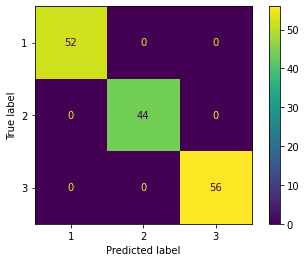

In [155]:
disp_model.plot() 

In [156]:
cm_clf_test=confusion_matrix(Y_test, clf_X_test_pred)

In [157]:
cm_clf_test

array([[52,  0,  0],
       [ 0, 44,  0],
       [ 0,  0, 56]], dtype=int64)

In [158]:
disp_clf = ConfusionMatrixDisplay(confusion_matrix=cm_clf_test, display_labels=model.classes_)

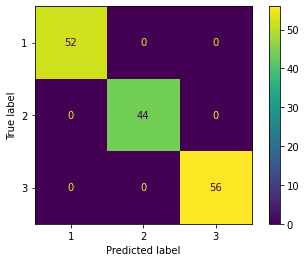

In [159]:
disp_clf.plot() 

In [160]:
cm_knn_test=confusion_matrix(Y_test, knn_X_test_pred)

In [161]:
cm_knn_test

array([[51,  1,  0],
       [ 0, 43,  1],
       [ 0,  0, 56]], dtype=int64)

In [162]:
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn_test, display_labels=model.classes_)

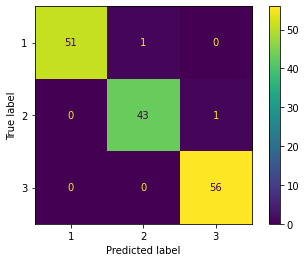

In [163]:
disp_knn.plot()

In [164]:
print(metrics.classification_report(Y_test, clf_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      1.000     1.000     1.000        52
           2      1.000     1.000     1.000        44
           3      1.000     1.000     1.000        56

    accuracy                          1.000       152
   macro avg      1.000     1.000     1.000       152
weighted avg      1.000     1.000     1.000       152



In [165]:
print(metrics.classification_report(Y_test, knn_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      1.000     0.981     0.990        52
           2      0.977     0.977     0.977        44
           3      0.982     1.000     0.991        56

    accuracy                          0.987       152
   macro avg      0.987     0.986     0.986       152
weighted avg      0.987     0.987     0.987       152



In [166]:
print(metrics.classification_report(Y_test, model_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      1.000     1.000     1.000        52
           2      1.000     1.000     1.000        44
           3      1.000     1.000     1.000        56

    accuracy                          1.000       152
   macro avg      1.000     1.000     1.000       152
weighted avg      1.000     1.000     1.000       152



In [167]:
#model_cvp=cross_val_predict(model, X_test, Y_test, cv=3, method="predict")

In [168]:
#roc_auc_score(Y_test, model_pred_proba, multi_class='ovr')